## Carga de datos

In [335]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [336]:
data = pd.read_csv('./data/crop_recommendation.csv')
data

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


## EDA

In [337]:
data['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

Se observan los 22 cultivos únicos de la columna 'label'.

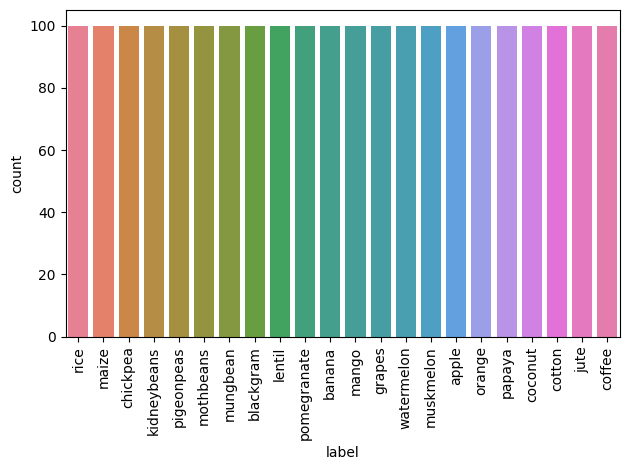

In [338]:
plt.figure(layout='tight')
sns.countplot(data=data, x='label', hue='label')
plt.xticks(rotation=90)
plt.show()

In [339]:
print(data['label'].value_counts())

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


Presenta una distribución balanceada de entradas de cada categoría, con 100 en cada caso.

In [340]:
num_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

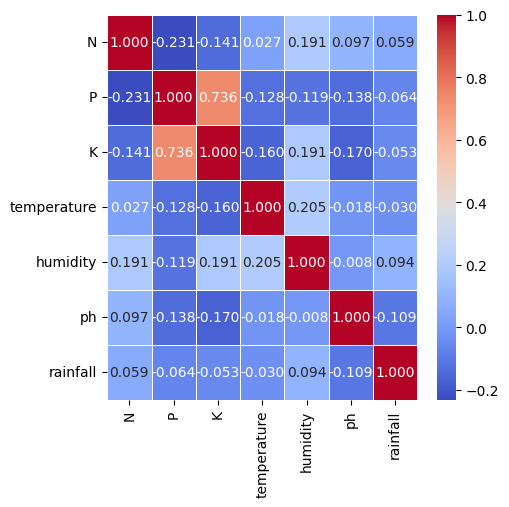

In [341]:
# Confusion Matrix
plt.figure(figsize=(5,5))
sns.heatmap(data=data[num_features].corr(), annot=True, cmap='coolwarm', linewidths=.5, fmt=".3f")
plt.show()

Se observa cierta correlación entre variables numéricas, destacando Fósforo - Potasio como positiva y Nitrógeno - Fósforo como la más negativa.

In [342]:
print(data.isna().sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


No posee valores NULL.

C:\Users\ale_r\AppData\Local\Temp\ipykernel_5468\3403982195.py:2: UserWarning: 
The palette list has fewer values (20) than needed (22) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=data, x='P', y='N', hue='label', palette=sns.color_palette("tab20", 20))


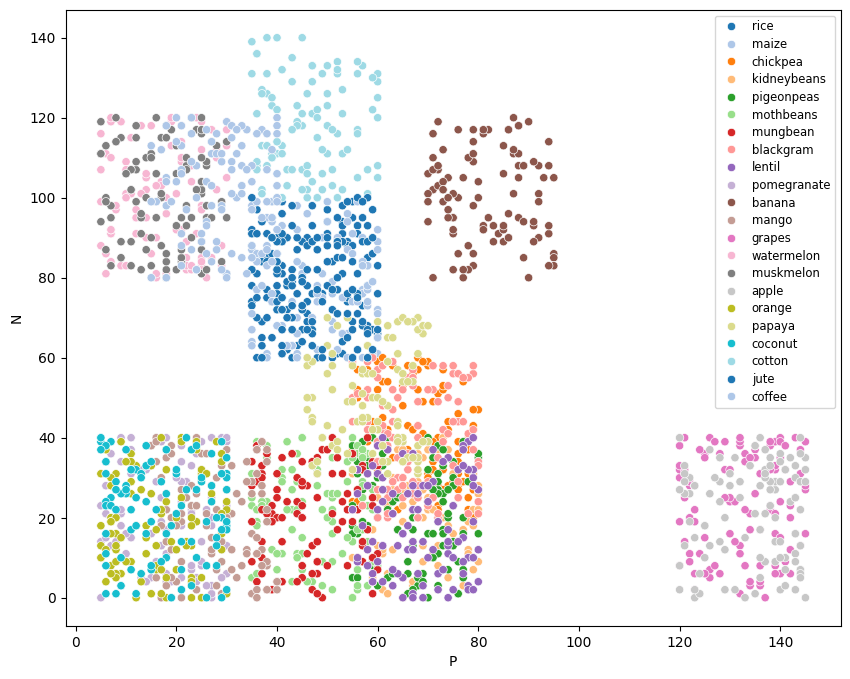

In [343]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=data, x='P', y='N', hue='label', palette=sns.color_palette("tab20", 20))
plt.legend(fontsize="small", labelspacing=0.4, borderpad=0.4)
plt.show()

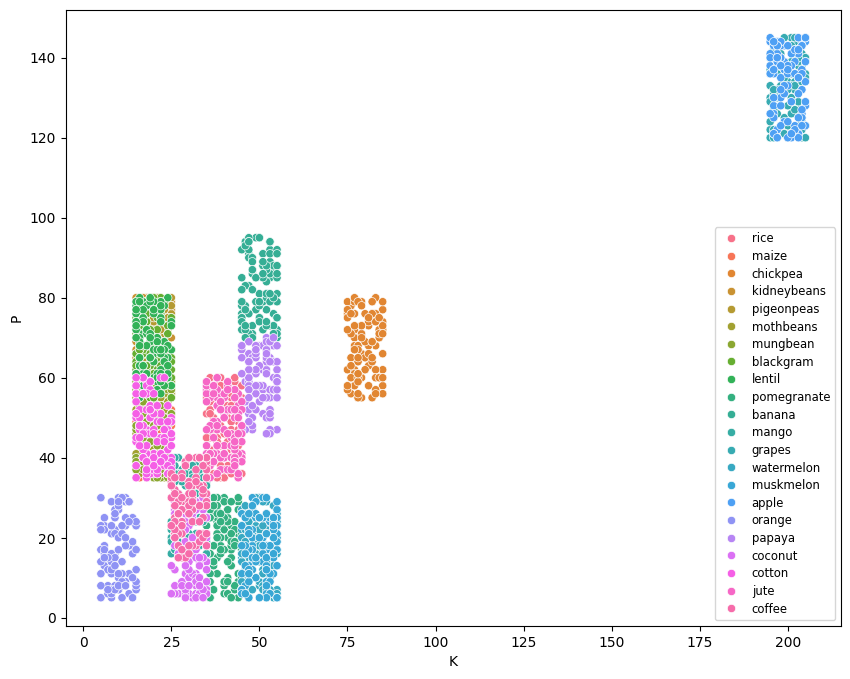

In [344]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=data, x='K', y='P', hue='label')
plt.legend(fontsize="small", labelspacing=0.4, borderpad=0.4)
plt.show()

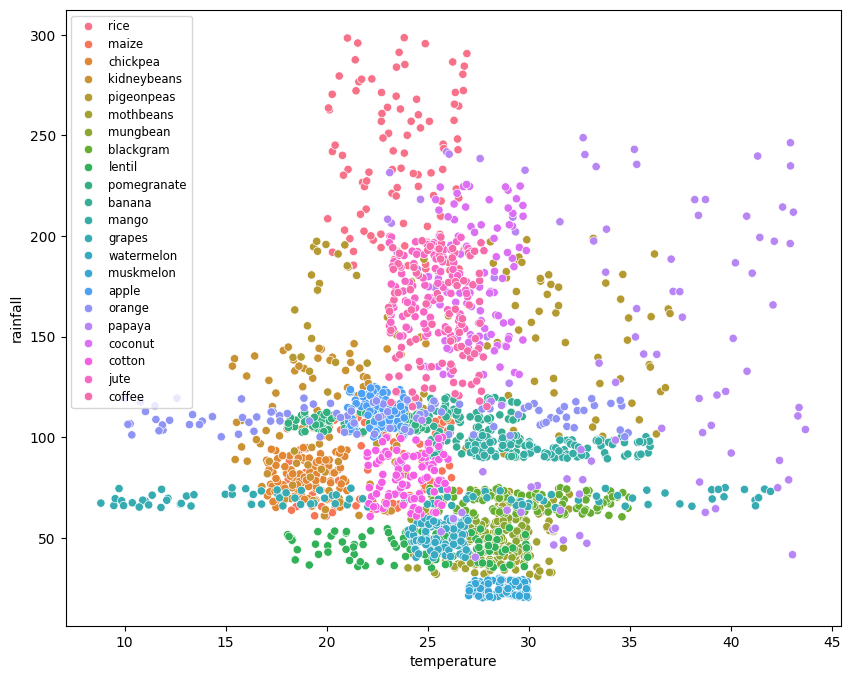

In [345]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=data, x='temperature', y='rainfall', hue='label')
plt.legend(fontsize="small", labelspacing=0.4, borderpad=0.4)
plt.show()

La distrIbución de ciertos elementos es tan marcada dado el carácter químico y condiciones bajo las que **debe** crecer cada cultivo, pues condiciones no ideales llevarían directamente al fracaso del ciclo de crecimiento.

C:\Users\ale_r\AppData\Local\Temp\ipykernel_5468\1794768169.py:3: UserWarning: 
The palette list has fewer values (20) than needed (22) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data, x = column, ax=axes[index//4, index%4], hue='label', palette=sns.color_palette("tab20", 20), legend=(index == 0))
C:\Users\ale_r\AppData\Local\Temp\ipykernel_5468\1794768169.py:3: UserWarning: 
The palette list has fewer values (20) than needed (22) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data, x = column, ax=axes[index//4, index%4], hue='label', palette=sns.color_palette("tab20", 20), legend=(index == 0))
C:\Users\ale_r\AppData\Local\Temp\ipykernel_5468\1794768169.py:3: UserWarning: 
The palette list has fewer values (20) than needed (22) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data, x = column, ax=axes[index//4, index%4], hue='label', palette=sns.color_palette("tab20", 20), legend=(index == 0))
C:\Users\ale_

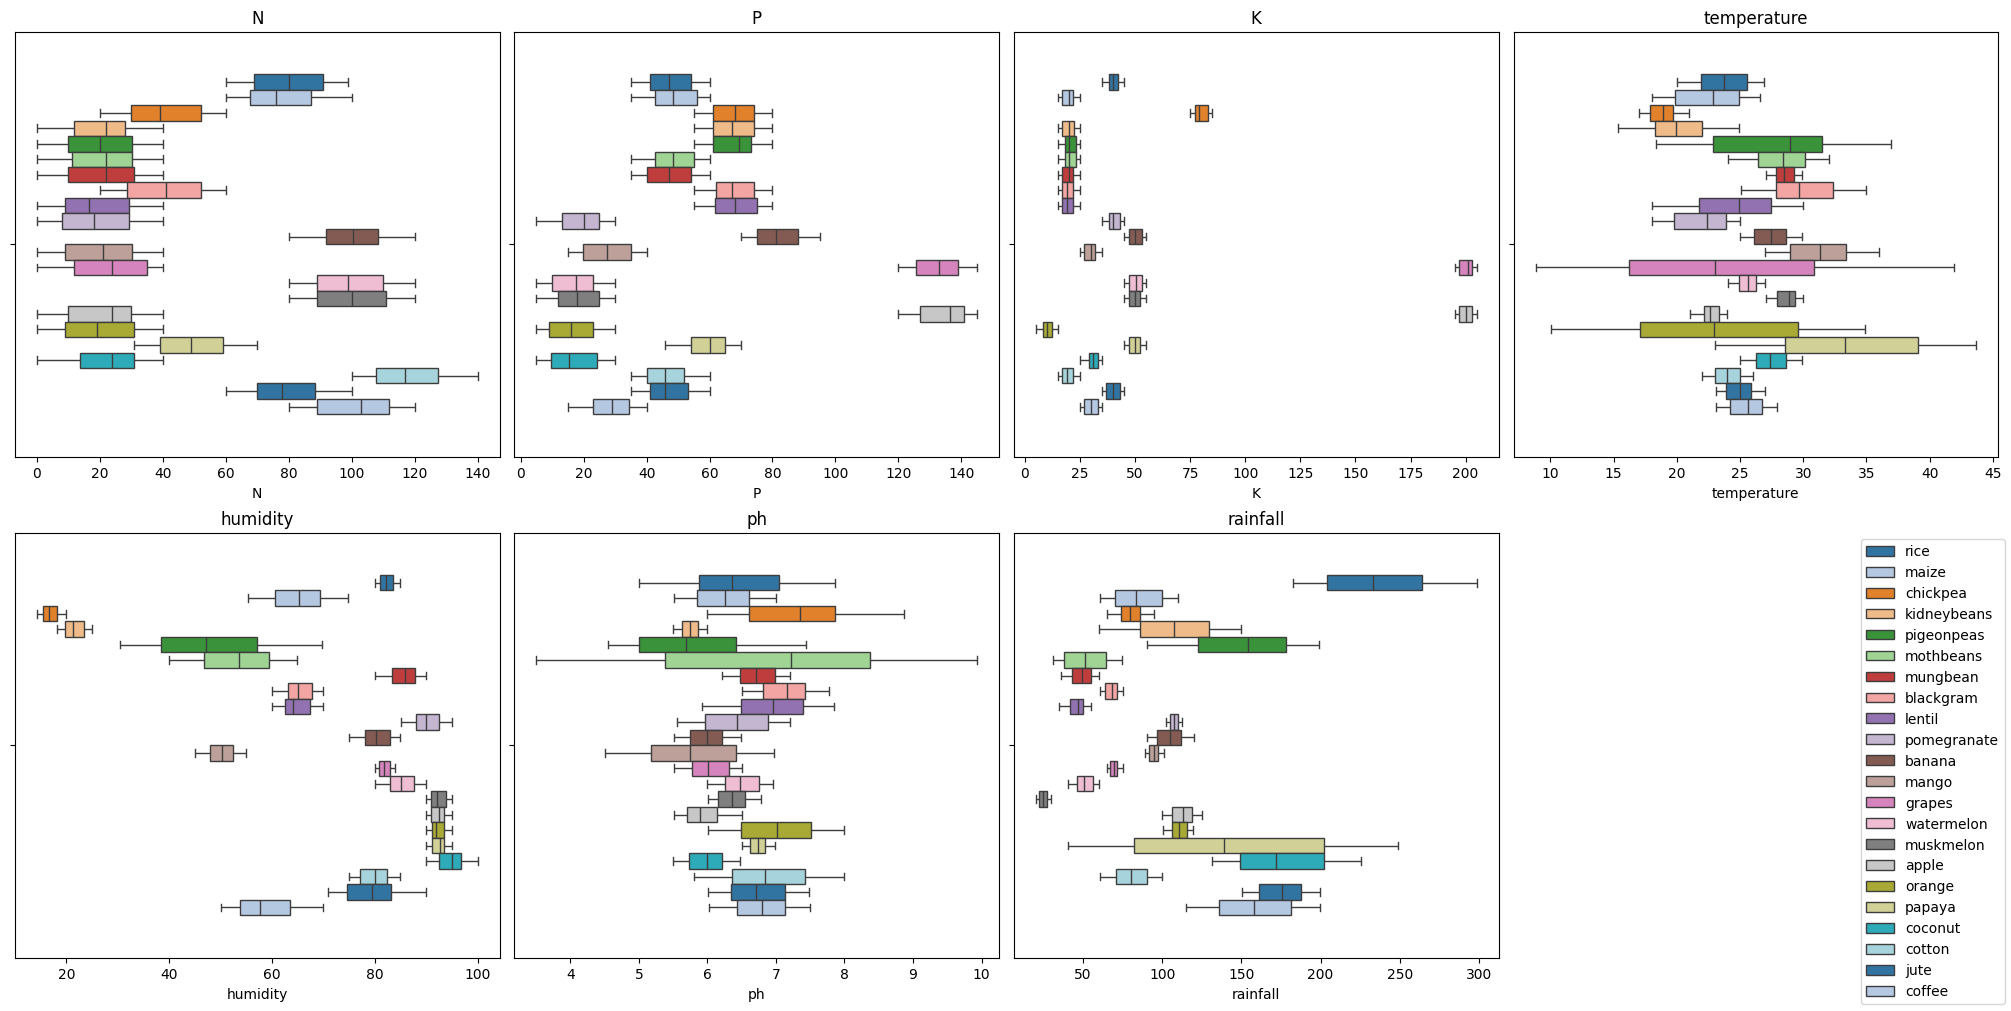

In [346]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)
for index, column in enumerate(data.drop(columns=["label"]).columns):
    sns.boxplot(data, x = column, ax=axes[index//4, index%4], hue='label', palette=sns.color_palette("tab20", 20), legend=(index == 0))
    axes[index//4, index%4].set_title(column)
handles, labels = axes[0, 0].get_legend_handles_labels()

axes[1, 3].axis("off")
axes[0, 0].legend_.remove()
fig.legend(handles, labels, loc="lower right")

plt.show()

No se observan outliers en ninguna de los cultivos.

## 1: Regresión logística 

In [347]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [348]:
# Definir variable objetivo
X = data.drop(columns=['label'])
y = data.label
X.shape, y.shape

((2200, 7), (2200,))

In [349]:
# definir pipeline y parámetros para GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

params = {
        "model__solver": ["saga"],  # el solver saga es el único que soporta elasticnet!
        "model__penalty": ["elasticnet"],  #penalty fue deprecado en 1.8 y eliminado en 1.10 (estamos usando 1.9)
        "model__l1_ratio": [0, 0.3, 0.5, 0.7, 1],
        "model__max_iter": [2000, 5000],
        "model__C": [0.1, 1, 10, 100],
    }


### Cross Val para buscar hiperparámetros

In [350]:
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Grid Search para encontrar los mejores parámetros del modelo
grid_lr = GridSearchCV(pipeline, params, cv=5, scoring="roc_auc_ovr", n_jobs=12, verbose = 1)
grid_lr.fit(X_train, y_train)
display(grid_lr.best_params_)
display(grid_lr.best_score_)
pipeline = grid_lr.best_estimator_

"""
Output de mejores paramétodos y score:

{'model__C': 100,
 'model__l1_ratio': 1,
 'model__max_iter': 2000,
 'model__penalty': 'elasticnet',
 'model__solver': 'saga'}
 np.float64(0.9998241926623432)
"""

Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\ale_r\anaconda3\envs\envIA\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


{'model__C': 100,
 'model__l1_ratio': 1,
 'model__max_iter': 2000,
 'model__penalty': 'elasticnet',
 'model__solver': 'saga'}

np.float64(0.9998241926623432)

"\nOutput de mejores paramétodos y score:\n\n{'model__C': 100,\n 'model__l1_ratio': 1,\n 'model__max_iter': 2000,\n 'model__penalty': 'elasticnet',\n 'model__solver': 'saga'}\n np.float64(0.9998241926623432)\n"

Para obtener los mejores hiperparámetros en la Regresión Logística se realiza Cross Validation con 5 particiones y las métricas de selección accuracy, f1_macro y **roc_auc_ovr** correspondiente al resultado en el output.
La mejor configuración encontrada correspondió a lo expuesto en Output de la celda anterior, donde se obtiene que el desempeño mejor durante la validación cruzada fue de **roc_auc_ovr = 0.9998**, que indica que el modelo es capaz de discriminar muy eficientemente entre las clases del dataset.


Adicionalmente se obtiene un $l1\_ratio = 1$, que hace que la penalización de ElasticNet sea equivalente a una regularización de tipo L1 (Lasso).



In [351]:
from sklearn.metrics import classification_report, accuracy_score
#predicciones
y_pred = pipeline.predict(X_test)

#mostrar resultados
print(classification_report(y_test, y_pred))

#accuracy 
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.90      0.95      0.93        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.87      0.87      0.87        23
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      1.00      1.00        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       0.96    


___
### Resultados
| Scoring en CV | Desempeño promedio en CV | Accuracy obtenida |
| ---------------- | ---------------- | -------- |
| Accuracy | 0.9823 | 0.970  |
| f1_macro | 0.9821 | 0.970 | 
| **roc_auc_ovr** | 0.9998 | **0.975**|


En la tabla anterior se presentan los resultados obtenidos para el modelo de Regresión Logística utilizando distintos criterios de selección durante el proceso de Cross Validation. Se observa que las configuraciones seleccionadas mediante accuracy y f1_macro alcanzaron una accuracy de 0.970 en el conjunto de prueba, mientras que la configuración seleccionada mediante **roc_auc_ovr obtuvo una accuracy de 0.975**.

Este resultado sugiere que para la Regresión Logística, optimizar la capacidad de discriminación entre clases mediante roc_auc_ovr permitió encontrar un modelo con mejor desempeño predictivo. Según esto, se considera que **el modelo obtenido mediante optimización por roc_auc_ovr es el más adecuado para el objetivo propuesto**.

### Importancia de características

In [352]:
# Nota: Se hizo uso de inteligencia artificial en la construcción del dataframe
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(pipeline.named_steps['model'].coef_).mean(axis=0) 
}).sort_values(by='importance', ascending=False)

print(feature_importance)

       feature  importance
4     humidity    9.381199
1            P    7.876794
2            K    7.806921
6     rainfall    7.758474
0            N    7.395120
3  temperature    2.245022
5           ph    1.054167


La sección anterior muestra la importancia de las variables en la clasificación de cultivos para el modelo de Regresión Logística.

Los datos indican que las variables más influyentes en la clasificación de cultivos son principalmente las relacionadas a la **disponibilidad de agua**(humidity y rainfall) y **nutrientes del suelo**(P,K,N). Mientras que las menos influyentes (que aportan menos a la decisión final) corresponden a temperature y ph.

In [353]:
# validacion cruzada 
from sklearn.model_selection import cross_val_score

cv = cross_val_score(pipeline, X_train, y_train, scoring='accuracy', cv=5)

print("cv.mean:", cv.mean(), "cv.std:", cv.std())

#cv.mean: 0.9818181818181818 cv.std: 0.006377825091091925


c:\Users\ale_r\anaconda3\envs\envIA\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\ale_r\anaconda3\envs\envIA\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\ale_r\anaconda3\envs\envIA\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\ale_r\anaconda3\envs\envIA\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


cv.mean: 0.9818181818181818 cv.std: 0.006377825091091925


c:\Users\ale_r\anaconda3\envs\envIA\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


En la validación cruzada se obtiene que **el modelo promedia un 0.9818 de exactitud**, lo cual evidencia que el modelo es robusto al ser evaluado en distintos conjuntos de datos, descartando posibilidades de overitting.

Asimismo, la validación cruzada muestra que el modelo presenta una **desviación estándar de 0.0063**, lo cual refleja una fluctuación mínima en el desempeño de sus predicciónes.

## 2: KNN

In [354]:
from sklearn.neighbors import KNeighborsClassifier

In [355]:
# Definir pipeline y parámetros para GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

params = {
        "model__n_neighbors": [3, 5, 7, 9,11, 13, 15],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan", "minkowski"]
}


In [356]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Grid Search para encontrar los mejores parámetros del modelo
grid_knn = GridSearchCV(pipeline, params, cv=5, scoring="f1_macro", n_jobs=12, verbose = 1)
grid_knn.fit(X_train, y_train)
display(grid_knn.best_params_)
display(grid_knn.best_score_)
pipeline = grid_knn.best_estimator_

Fitting 5 folds for each of 42 candidates, totalling 210 fits


{'model__metric': 'manhattan',
 'model__n_neighbors': 3,
 'model__weights': 'distance'}

np.float64(0.9828923060172319)

De lo anterior se obtiene que el mejor modelo de KNN para este dataset se obtiene a través de la métrica de distancia 'Manhattan', con vecinos $k = 3$, y con el calculo de los pesos según distancia (los vecinos más cercanos pesan más).

In [357]:
# Predicciones
y_pred = pipeline.predict(X_test)

# Mostrar resultados
print(classification_report(y_test, y_pred))

# Accuracy 
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.88      1.00      0.94        23
 kidneybeans       0.91      1.00      0.95        20
      lentil       0.73      1.00      0.85        11
       maize       1.00      0.95      0.98        21
       mango       0.95      1.00      0.97        19
   mothbeans       1.00      0.88      0.93        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

___
### Resultados

| Scoring en CV | Desempeño promedio en CV | Accuracy obtenida |
| ---------------- | ----- | -------- |
| **Accuracy** | 0.9829 | **0.975** |
| **f1_macro** | 0.9828 | **0.975** | 
| roc_auc_ovr | 0.9999 | 0.959 |


En la tabla anterior se observan los resultados obtenidos mediante Cross Validation para evaluar distintas configuraciones del modelo KNN. Los mejores resultados en el conjunto de prueba se obtuvieron al optimizar los hiperparámetros utilizando las métricas accuracy y f1_macro, alcanzando una **accuracy de 0.975** en ambos casos. Por otro lado, al utilizar roc_auc_ovr como criterio de optimización, la accuracy obtenida fue de 0.959.

A diferencia de lo observado en la Regresión Logística, en KNN la optimización mediante roc_auc_ovr no condujo a la mejor capacidad predictiva. Los mejores resultados se obtuvieron al optimizar directamente accuracy o f1_macro, lo que indica que estas métricas resultan más adecuadas para seleccionar hiperparámetros cuando el objetivo final es maximizar la cantidad de clasificaciones correctas. Por esta razón, la configuración seleccionada mediante accuracy o f1_macro fue considerada la más apropiada para este modelo.

*Se omite el analisis de feature_importance debido a la naturaleza de KNN de basarse en cercanía con otros puntos y no aprender parámetros internos*

In [358]:
# validacion cruzada 
from sklearn.model_selection import cross_val_score

cv = cross_val_score(pipeline, X_train, y_train, scoring='accuracy', cv=5)

print("cv.mean:", cv.mean(), "cv.std:", cv.std())

cv.mean: 0.9829545454545455 cv.std: 0.003112059985824815


La validación cruzada muestra que el modelo KNN obtenido posee una **precisión muy alta (0.9829 de promedio)**, lo cual confirma que su desempeño es robusto en distintos escenarios.

Además, la **desviación estándar es mínima (0.0031)**, lo que significa que la variación del desempeño en la mejor y peor clasificación del modelo es ínfima. 

## 3: Decision Tree

In [359]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [360]:
# Separación de los conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [361]:
dt_model = DecisionTreeClassifier(max_depth= 50, random_state=42) # Por defecto, trabaja con gini como criterio
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,50
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [362]:
# Desempeño
from sklearn.metrics import confusion_matrix

In [363]:
# Resultados
y_pred = dt_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))

[[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0  1  0  0 22  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0

In [364]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       0.96      1.00      0.98        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      0.96      0.94        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

### Resultados 

A través de la tabla anterior (*classification_report*) es posible observar que el modelo alcanza una alta accuracy (0.99) en la clasificación de cultivos. Así mismo, es posible concluir que las métricas precision, recall y f1-score son casi perfectas según macro avg y weighted avg.

*Es importante mencionar que weighted avg es casi equivalente a macro avg debido a la característica del dataset de ser balanceado exactitud en la cantidad de muestras*.

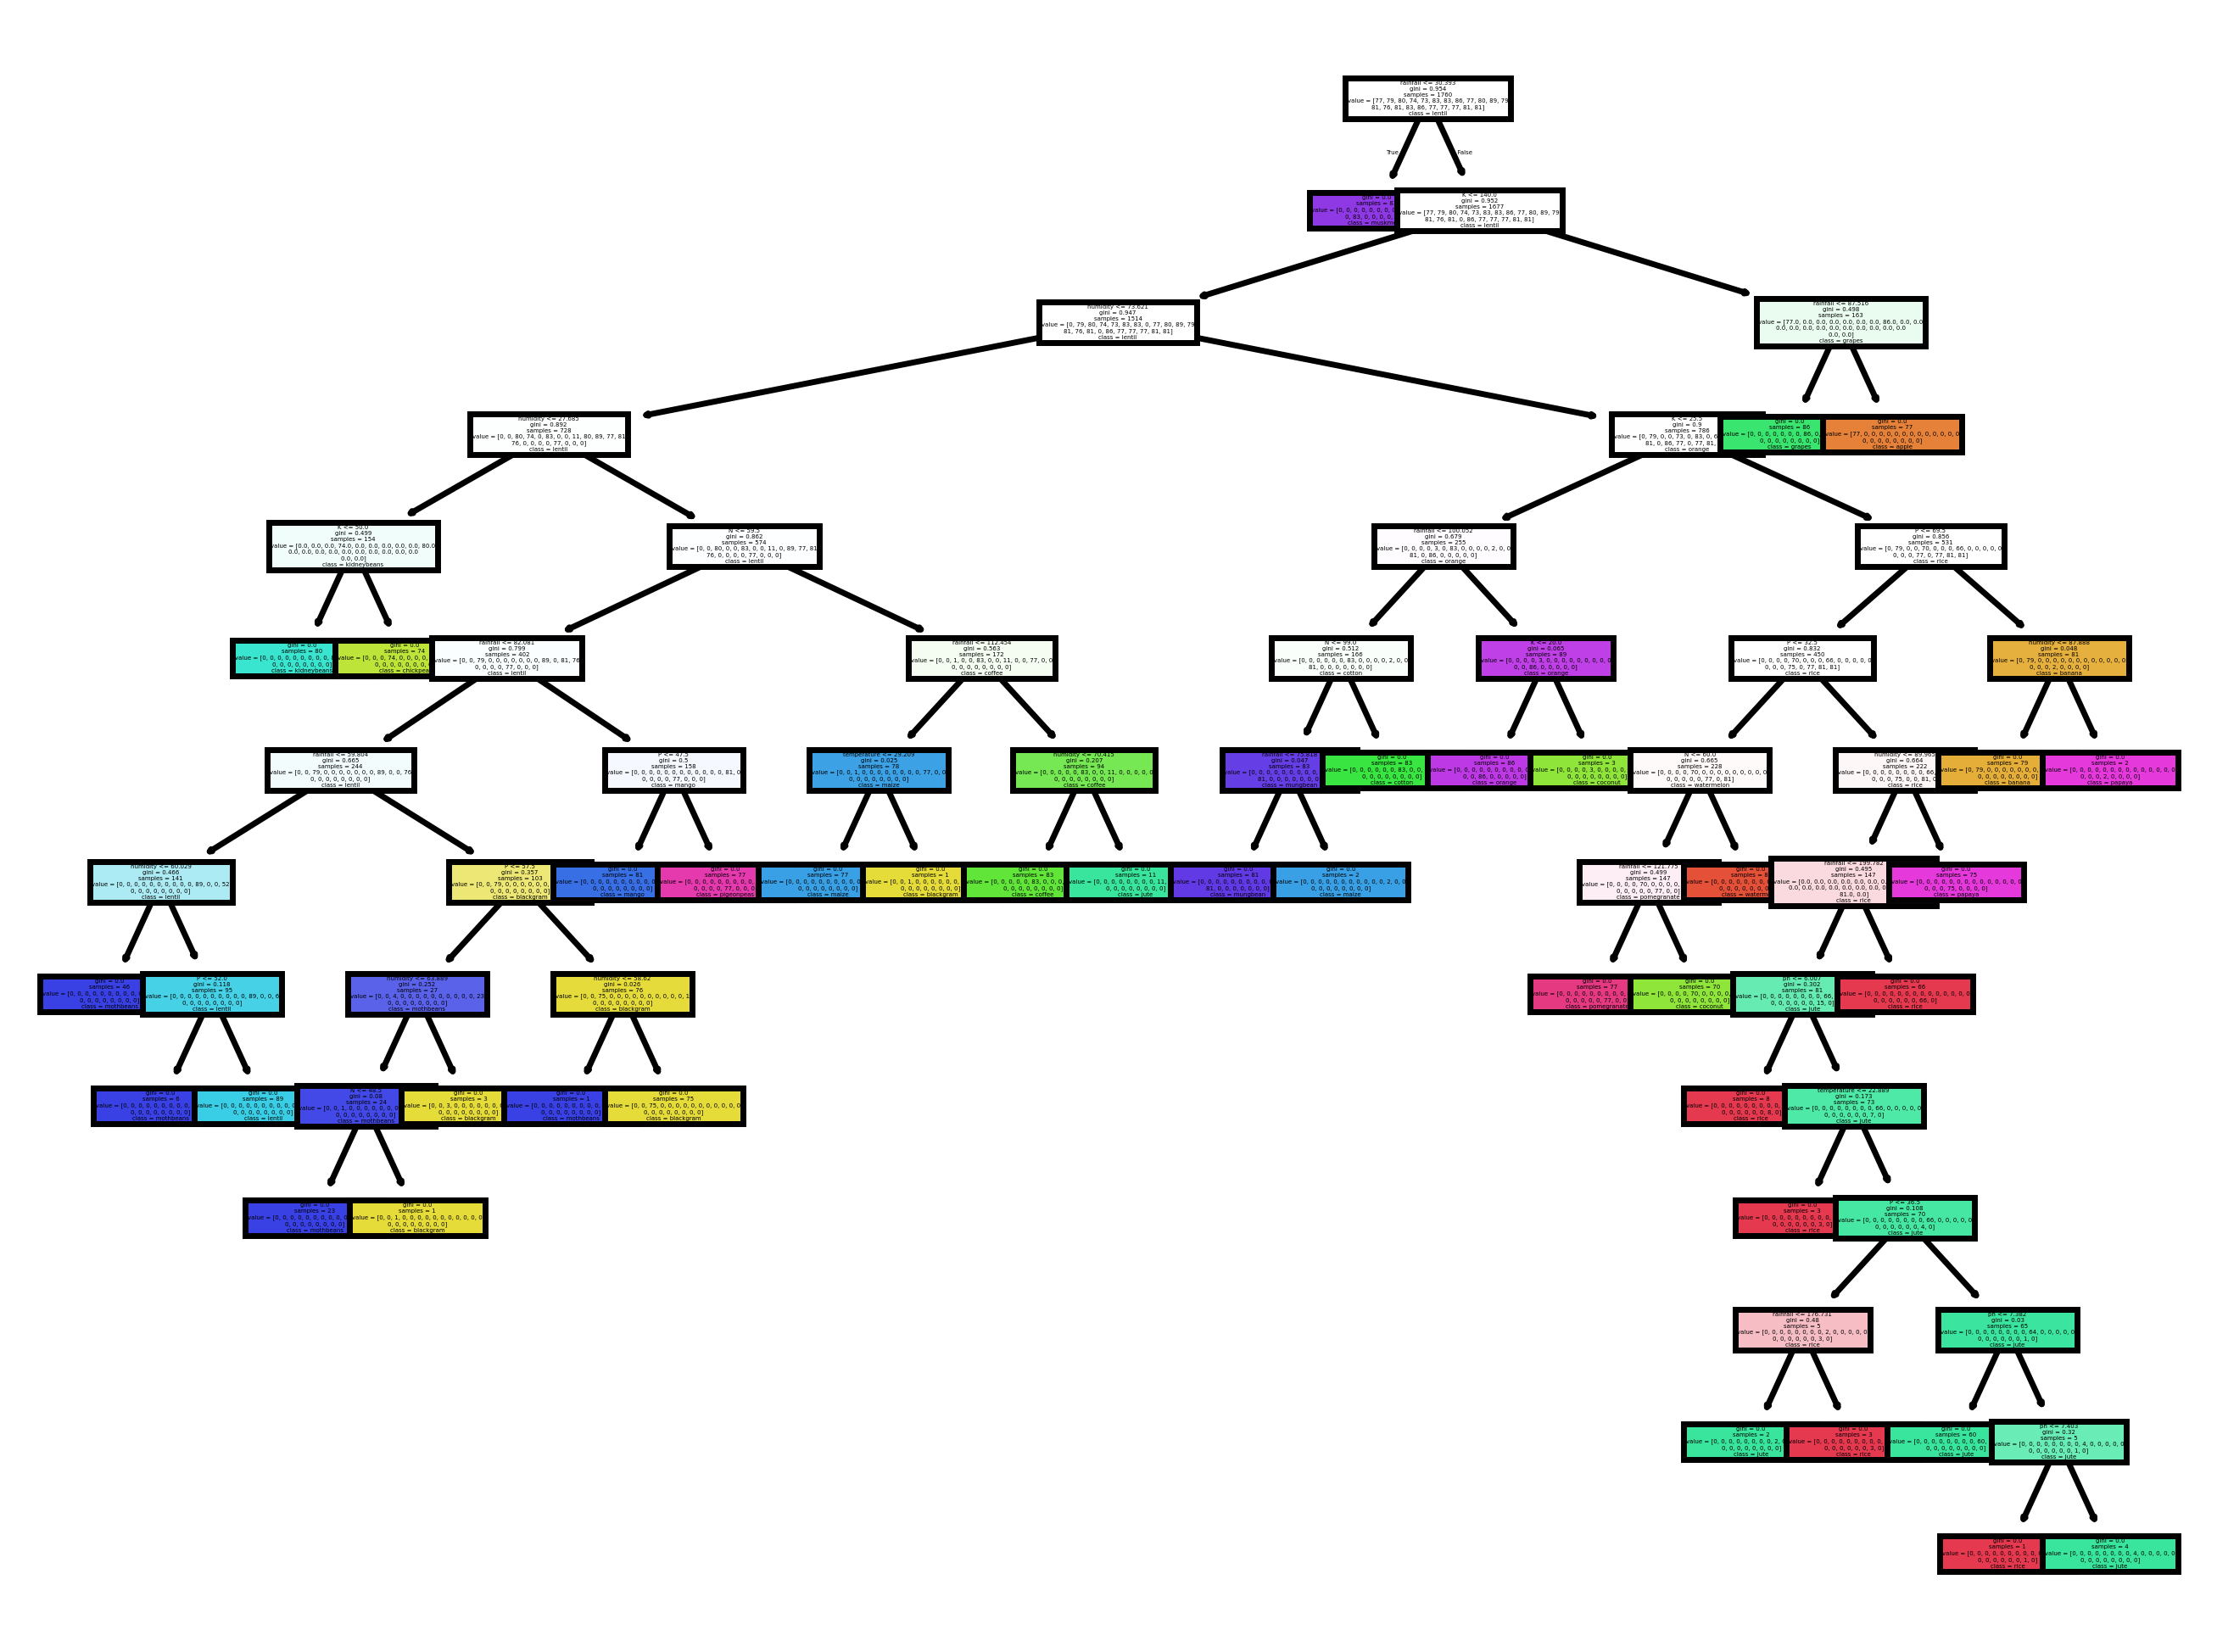

In [365]:
plt.figure(dpi=500)
plot_tree(dt_model, filled = True, feature_names= dt_model.feature_names_in_, class_names = dt_model.classes_)
plt.show()

In [366]:
# Score obtenido
dt_model.score(X_test, y_test)

0.9863636363636363

#### Pesos de columnas

In [367]:
# Peso de cada atributo
pd.DataFrame(dt_model.feature_importances_, index = X.columns)

,0
N,0.141650
P,0.162547
K,0.145078
temperature,0.004220
humidity,0.187216
ph,0.008189
rainfall,0.351099


El analisis de importancia de columnas muestra que las decisiones del modelo se basan principalmente en las necesidades de agua de los cultivos, específicamente de las precipitaciones (*rainfall*).

Por otro lado, los nutrientes del suelo (P,K,N) toman el segundo lugar en el orden de importancia para clasificar el cultivo mas apto en un terreno.

Al igual que en Regresión Logística, las características de temperatura y pH son variables con muy poco peso respecto al resto para la toma de decisiones. 

____
## Decision Tree - GridSearchCV

A continuación se realizarán pruebas para trabajar con los mejores estimadores.

In [368]:
params = {
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'max_depth' : [None, 15, 30, 50, 100],
    'splitter' : ['best', 'random']
}
grid_s = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=12, verbose=1, scoring='roc_auc_ovr')
grid_s.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 15, ...], 'splitter': ['best', 'random']}"
,scoring,'roc_auc_ovr'
,n_jobs,12
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [369]:
display(grid_s.best_params_)
display(grid_s.best_score_)
display(grid_s.best_estimator_.get_depth())

{'criterion': 'gini', 'max_depth': None, 'splitter': 'best'}

np.float64(0.9922030579320212)

13

El entrenamiento con GridSearchCV muestra que los mejores parámetros para el modelo de Decision Tree son:
- Criterio = Gini
- Profundidad = 13
- Splitter = 'best'

Además, muestra que estos parametros otorgan un valor de **roc_auc_ovr de 0.9922**.

In [370]:
# Validacion cruzada
from sklearn.model_selection import cross_val_score

In [371]:
cv = cross_val_score(grid_s, X_train, y_train, scoring='accuracy', cv=5)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [372]:
print(cv.mean(), cv.std())

0.9852272727272726 0.006327004957761406


In [373]:
# Predicciones
y_pred = grid_s.predict(X_test)

# Mostrar resultados
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       0.96      1.00      0.98        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      0.96      0.94        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

Gracias a las secciones anteriores y la validación cruzada es posible determinar que el modelo obtiene una exactitud (accuracy) muy alta (0.985) en un conjunto de datos que no ha visto. Esto sugiere que el modelo es robusto y **no posee síntomas de overfitting**. Además, la distribución estándar demuestra que la variación del desempeño del modelo al predecir es mínima.


## 4: Random Forest

In [374]:
from sklearn.ensemble import RandomForestClassifier

In [375]:
# Crear y entrenar clasificador
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [376]:
# Score que alcanza el modelo
y_pred = rf_model.predict(X_test)
rf_model.score(X_test, y_test)

0.9931818181818182

In [377]:
# Resultados
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

In [378]:
# Peso de cada columna al Random Forest
pd.DataFrame(rf_model.feature_importances_, index = X.columns)

,0
N,0.108859
P,0.143622
K,0.181222
temperature,0.075682
humidity,0.211279
ph,0.052301
rainfall,0.227036


El mayor peso lo sigue poseyendo 'rainfall' seguido de 'humidity', más no alcanzan números tan altos como en el caso del Decision Tree.

### Random Forest - GridSearchCV

In [379]:
params = {
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'max_depth' : [None, 15, 30, 50, 100],
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), params, n_jobs=12, verbose=1, scoring='accuracy')
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 15, ...]}"
,scoring,'accuracy'
,n_jobs,12
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [380]:
display(grid_rf.best_params_)
display(grid_rf.best_score_)

{'criterion': 'gini', 'max_depth': 15}

np.float64(0.9954545454545455)

El entrenamiento con GridSearchCV muestra que los mejores parámetros para el modelo de Decision Tree son:
- Criterio = Gini
- Profundidad = 15

Además, muestra que estos parametros otorgan un valor de **accuracy de 0.995**.

In [381]:
cv_rf = cross_val_score(grid_rf, X_train, y_train, scoring='accuracy', cv=5)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits


In [382]:
print(cv_rf.mean(), cv_rf.std())

0.9943181818181819 0.005959141182784973


La validación cruzada muestra resultados muy favorables para el desempeño al clasificar, tanto en exactitud como en distribución estándar.

In [383]:
pd.DataFrame(grid_rf.best_estimator_.feature_importances_, index = X.columns)

,0
N,0.108650
P,0.142226
K,0.181841
temperature,0.073635
humidity,0.213023
ph,0.052725
rainfall,0.227900


Con el GridSearch, se obtienen pesos bastante similares al caso normal. Nuevamente se obtiene que las precipitaciones son claves para la predicción.

In [384]:
# Predicciones
y_pred = grid_rf.predict(X_test)

# Mostrar resultados
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

## Resultados

Los resultados muestran que el modelo de Random Forest alcanzó el mejor desempeño entre los 4 modelos evaluados.

Posee una exactitud muy alta (0.994 de accuracy) y distribución estándar muy baja (0.0059), lo que lo convierte en el modelo más robusto de los 4.

___
## Curva ROC AUC

Por motivos de que son 22 cosechas distintas posibles, se probará comparar el desempeño con respecto a la clase 'rice'

In [385]:
from sklearn.metrics import roc_curve, auc

In [386]:
rice_bin = (y_test == "rice").astype(int)

In [387]:
lr_rice_idx = list(grid_s.classes_).index("rice") # Para Tomar las entradas específicas (Decision Tree)
lr_score = grid_lr.predict_proba(X_test)[:, lr_rice_idx]

knn_rice_idx = list(grid_knn.classes_).index("rice") # Para Tomar las entradas específicas (Random Forest)
knn_score = grid_knn.predict_proba(X_test)[:, knn_rice_idx]

dt_rice_idx = list(grid_s.classes_).index("rice") # Para Tomar las entradas específicas (Decision Tree)
dt_score = grid_s.predict_proba(X_test)[:, dt_rice_idx]

rf_rice_idx = list(grid_rf.classes_).index("rice") # Para Tomar las entradas específicas (Random Forest)
rf_score = grid_rf.predict_proba(X_test)[:, dt_rice_idx]

In [388]:
# True Y False Positive Rate, 
# Nota: funciones obtenidas con uso de inteligencia artificial
lr_fpr, lr_tpr, _ = roc_curve(rice_bin, lr_score)
auc_lr = auc(lr_fpr, lr_tpr)

knn_fpr, knn_tpr, _ = roc_curve(rice_bin, knn_score)
auc_knn = auc(knn_fpr, knn_tpr)

dt_fpr, dt_tpr, _ = roc_curve(rice_bin, dt_score)
auc_dt = auc(dt_fpr, dt_tpr)

rf_fpr, rf_tpr, _ = roc_curve(rice_bin, rf_score)
auc_rf = auc(rf_fpr, rf_tpr)

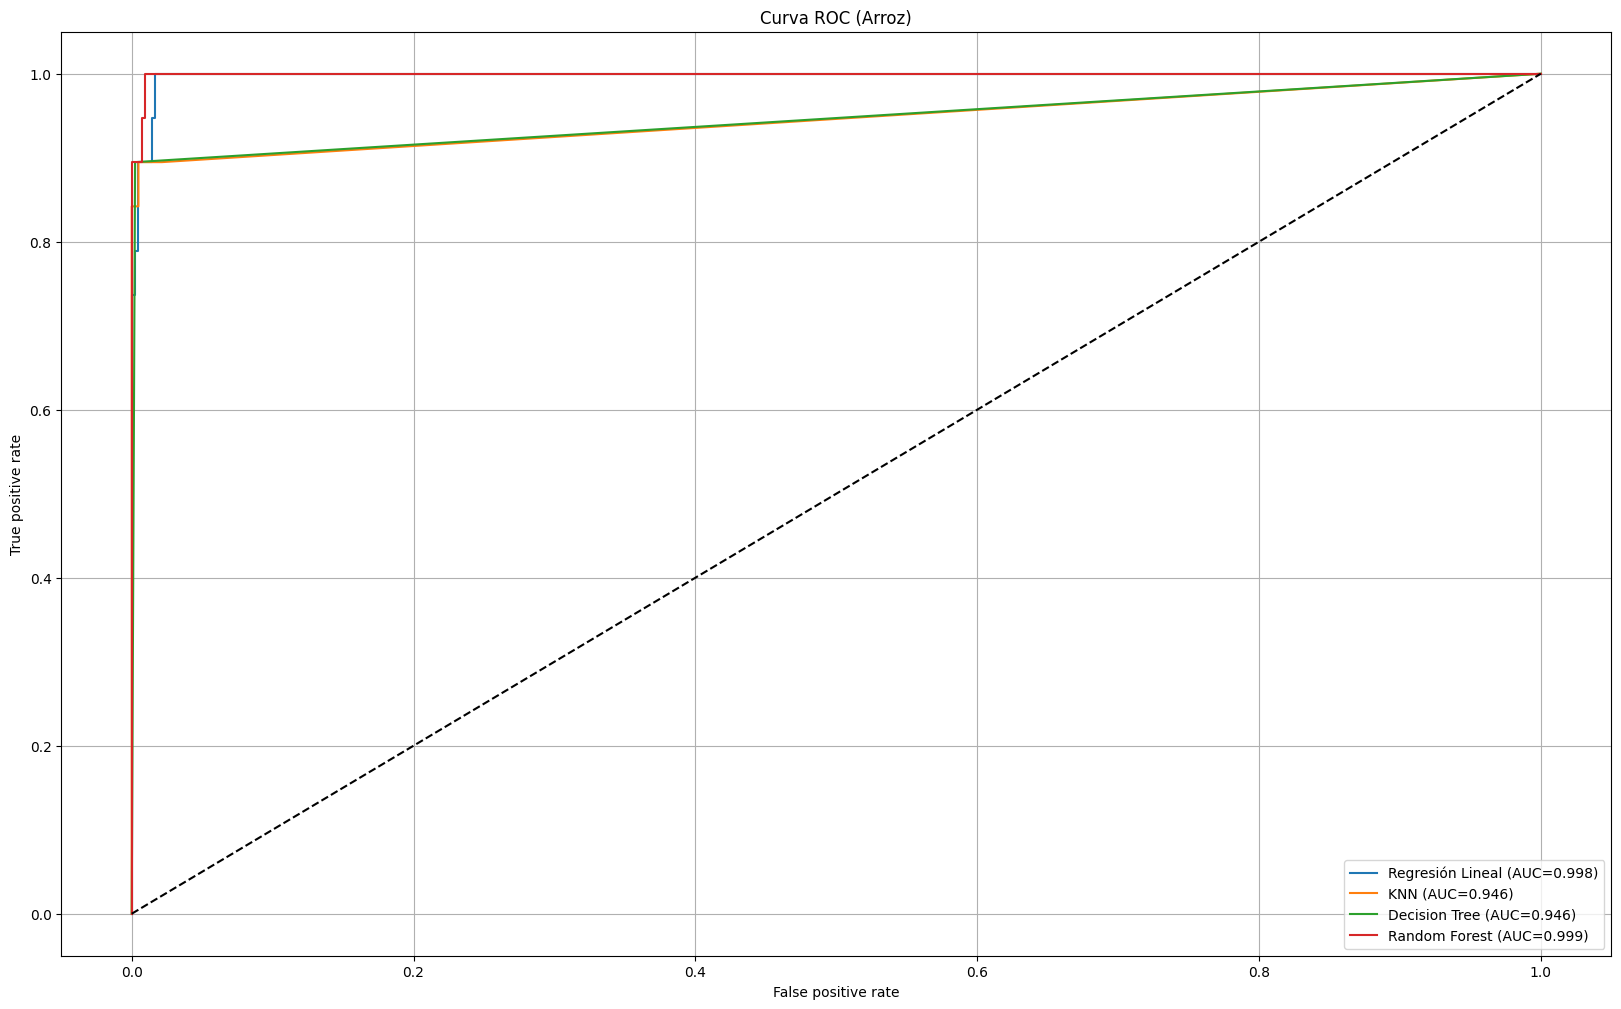

In [389]:
# Nota: Se hizo uso de Inteligencia artificial para la obtención de funciones de gráficos
plt.figure(figsize=(20,12))

plt.plot(lr_fpr, lr_tpr,
         label=f'Regresión Lineal (AUC={auc_lr:.3f})')

plt.plot(knn_fpr, knn_tpr,
         label=f'KNN (AUC={auc_knn:.3f})')

plt.plot(dt_fpr, dt_tpr,
         label=f'Decision Tree (AUC={auc_dt:.3f})')

plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC={auc_rf:.3f})')

plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Curva ROC (Arroz)')
plt.legend()
plt.grid(True)

plt.show()

In [390]:
# Área bajo cada curva
print('Área bajo la curva de la Regresión Lineal:', auc_lr)
print('Área bajo la curva del KNN:', auc_knn)
print('Área bajo la curva del Decision Tree:', auc_dt)
print('Área bajo la curva del Random Forest:', auc_rf)

Área bajo la curva de la Regresión Lineal: 0.9977497187148393
Área bajo la curva del KNN: 0.9459932491561446
Área bajo la curva del Decision Tree: 0.9461807725965746
Área bajo la curva del Random Forest: 0.9991248906113265


Observando así un mejor desempeño con el Random Forest, pudiendo llegar al concenso de que los mm de agua de las precipitaciones en conjunto al porcentaje de humedad son los que aportan más a la clasificación, aún más si se trabajan con un peso no tan alto respecto al resto.